In [1]:
# Trial 2

# import everything first:
import numpy as np
import astropy.constants as const
import astropy.units as u

# Load the constants in astronomy units


G        = const.G.cgs.value               # cm^3 g^-1 s^-2
sigmaB   = const.sigma_sb.cgs.value        # erg cm^-2 s^-1 K^-4
kB       = const.k_B.cgs.value             # erg K^-1
mH       = const.m_p.cgs.value             # g  (mass of proton ~ hydrogen atom)

M_jup    = const.M_jup.cgs.value           # g
R_jup    = const.R_jup.cgs.value           # cm
L_sun    = const.L_sun.cgs.value           # erg/s
au       = const.au.cgs.value              # cm

sec_per_yr = (1 * u.yr).to(u.s).value      # s

# Luminosity
# T_irr(R)
#T_ext(r)
#T_eff(r)
# Sigma(r)
#T_c(r)
# Tb(r)
# F_nu
# F_nu (integrated over disc)




# 1. Create radial grid between Rin and Rout
R = np.geomspace(Rin, Rout, 100)  # cm

# 2. Calculate T_ext(R) 

if mode == "b":
        L_irr = G * M_p * Mdot_p / (2.0 * R_p)
    elif mode == "no_b":
        L_irr = 0.0
    elif mode == "planet":
        L_irr = Lplanet

T_irr = 0.0 if L_irr == 0.0 else (L_irr / (40*np.pi*sigmaB*R**2))**0.25

print(f'L_irr = {L_irr/L_sun:.2e} L_sun')

T_ext = (T_irr**4 + T_ISM**4)**0.25  # K

# 3. Calculate T_eff(R)

Teff = ((3.0 * G * M_p * Mdot_p) / (8.0 * np.pi * sigmaB * R**3) * (1.0 - np.sqrt(R_in / R)))**0.25  # K

# 4. Calculate Sigma(R)

Rgas = 8.314*1e7  # erg/(mol K)  (gas constant per mole by default, NEED CONFIRM UNIT)
term = (sigmaB * G * Mp * Mdot_p**3 / (alpha**4 * (np.pi**3) * kappa_R ))**0.2
mu_term = (mu / Rgas)**0.8
factor = (1 - np.sqrt(Rin/R))**(3/5)
Sigma6 = ((2**(7/5)) / (3**(6/5))) * term * mu_term * factor*R**(-3/5)

Omega = np.sqrt(G * Mp / R**3)
Sigma7 = (Mdot_p * mu * Omega) / (3.0 * np.pi * alpha * Rgas * T_ext)  # g/cm^2

Sigma = min(Sigma6, Sigma7)


# 5. Calculate T_c(R)
A = (9 * G * M_p * Mdot_p * Sigma * kappa_R) / (128 * np.pi * sigmaB * R**3)
f = (1.0 - np.sqrt(R_in / R))
T_c =  (A * f + T_ext**4)**0.25

# 6. Calculate T_b(R)

# works for lists or arrays
Sigma  = np.asarray(Sigma, dtype=float)
T_c     = np.asarray(T_c,    dtype=float)
T_eff   = np.asarray(T_eff,  dtype=float)
T_ext  = np.asarray(T_ext, dtype=float)

if not (Sigma.shape == T_c.shape == T_eff.shape == T_ext.shape):
    raise ValueError("Sigma, Tc, Teff, T_ext must have the same shape.")

# τ_mm = 0.5 κ_mm Σ   (dimensionless since κ_mm[AU^2/MJup] * Σ[MJup/AU^2] = 1)
tau_mm = 0.5 * kappa_mm * Sigma


# thin branch: Tb = 2 τ Tc
Tb_thin  = 2.0 * tau_mm * T_c

# thick branch: Tb^4 = (3/8)*(κ_R/κ_mm)*Teff^4 + T_ext^4
Tb_thick = ((3.0/8.0) * (kappa_R / kappa_mm) * Teff**4 + T_ext**4)**0.25

# hard switch at τ=0.5
Tb = np.where(tau_mm <= 0.5, Tb_thin, Tb_thick)  # where (condition, if true, if false)


# 7. Calulate Tb_avg over the disc

dR   = np.diff(R)
Rmid = 0.5*(R[:-1] + R[1:])
Tbmid= 0.5*(Tb[:-1] + Tb[1:])              # avg over segment
num  = np.sum(Tbmid * 2*np.pi * Rmid * dR) # ≈ ∫ Tb 2πR dR
den  = np.pi * (R_out**2)
Tb_avg = num / den

# 8. Calculate F_nu in Rayleigh-Jeans limit, integrated over the disc area

I_RJ = 2.0 * kB * Tb_avg / (lam_mm/10)**2  # erg cm^-2 s^-1 Hz^-1 sr^-1
# Surface flux (one face): F_nu = pi * I_nu
F_nu = np.pi * I_RJ          # erg s^-1 cm^-2 Hz^-1
# Integrate over disc area   ∫ F_nu 2πR dR

F_nu_mid = 0.5 * (F_nu[:-1] + F_nu[1:])  # avg over segment
F_nu_tot= np.sum(F_nu_mid* 2*np.pi * Rmid * dR)

# Output in units of mu Jy
d_pc = 140  #pc
pc_to_cm = 3.086e18  # cm/pc
F_nu_tot = F_nu_tot / (d_pc*pc_to_cm)**2 * 1e29  # mu Jy


Calculating disk properties...
Planet mass: 1.0 M_jup
Accretion rate: 1.0e-05 M_jup/yr
Inner radius: 1.0 R_jup
Outer radius: 0.12 AU
Distance: 140 pc
Wavelength: 1.3mm (λ = 0.13 cm)
Opacity: κ_mm = 0.0172 cm^2/g

L_irr = 1.39e-03 L_sun
Tb_avg = 436.2 K
F_nu_tot = 121.48 microJy


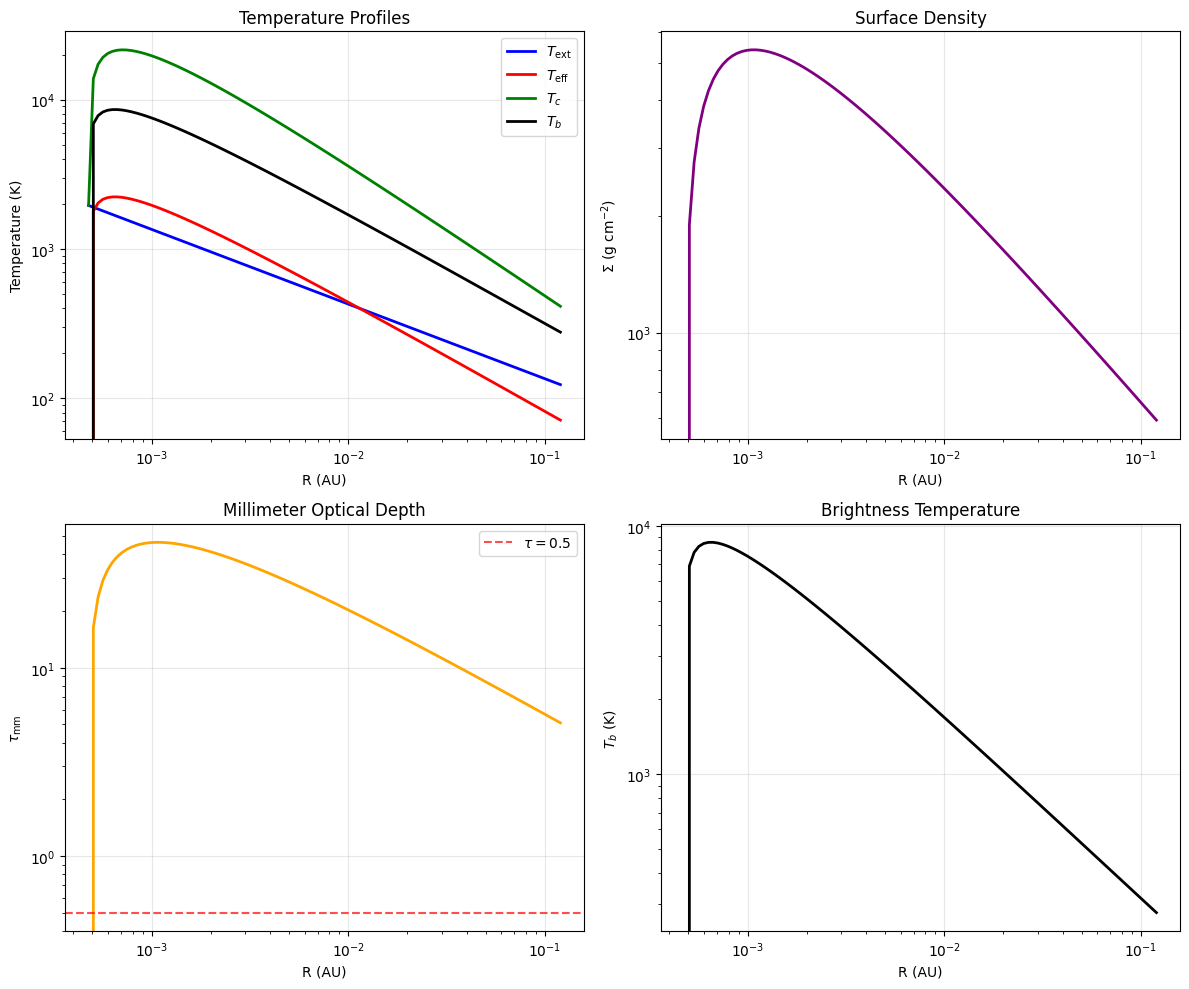

In [12]:
from matplotlib import pyplot as plt

# snaity check: plot the Ts, tau_mm ， sigma , Tb
def calculate_disk_properties(Mp, Mdot, alpha, kappaR, Rin, Rout, d_pc, 
                            mode="b", kappa_mm=1.0, lam_mm=1.3e-1, 
                            T_ISM=10.0, Lplanet=0.0, mu=2.3):
    """
    Calculate disk temperature profiles and millimeter flux.
    
    Parameters:
    -----------
    Mp : float
        Planet mass (g)
    Mdot : float  
        Accretion rate (g/s)
    alpha : float
        Viscosity parameter
    kappaR : float
        Rosseland opacity (cm^2/g)
    Rin : float
        Inner radius (cm)
    Rout : float
        Outer radius (cm)  
    d_pc : float
        Distance (pc)
    mode : str
        Irradiation mode: "b", "no_b", or "planet"
    kappa_mm : float
        Millimeter opacity (cm^2/g)
    lam_mm : float
        Wavelength (cm)
    T_ISM : float
        Interstellar medium temperature (K)
    Lplanet : float
        Planet luminosity (erg/s)
    mu : float
        Mean molecular weight
        
    Returns:
    --------
    dict : Dictionary containing R, temperatures, Sigma, tau_mm, Tb, F_nu_tot
    """
    
    # Constants
    G = 6.674e-8        # cm^3 g^-1 s^-2
    sigmaB = 5.67e-5    # erg cm^-2 s^-1 K^-4
    kB = 1.381e-16      # erg/K
    L_sun = 3.828e33    # erg/s
    R_p = 7.149e9       # Jupiter radius in cm
    AU = 1.496e13       # cm
    
    # 1. Create radial grid between Rin and Rout
    R = np.geomspace(Rin, Rout, 100)  # cm
    
    # 2. Calculate T_ext(R)
    if mode == "b":
        L_irr = G * Mp * Mdot / (2.0 * R_p)
    elif mode == "no_b":
        L_irr = 0.0
    elif mode == "planet":
        L_irr = Lplanet
    else:
        raise ValueError("mode must be 'b', 'no_b', or 'planet'")
    
    T_irr = 0.0 if L_irr == 0.0 else (L_irr / (40 * np.pi * sigmaB * R**2))**0.25
    
    print(f'L_irr = {L_irr/L_sun:.2e} L_sun')
    
    T_ext = (T_irr**4 + T_ISM**4)**0.25  # K
    
    # 3. Calculate T_eff(R)
    Teff = ((3.0 * G * Mp * Mdot) / (8.0 * np.pi * sigmaB * R**3) * 
            (1.0 - np.sqrt(Rin / R)))**0.25  # K
    
    # 4. Calculate Sigma(R)
    Rgas = 8.314e7  # erg/(mol K)
    
    # Sigma prescription 6 (optically thick)
    term = (sigmaB * G * Mp * Mdot**3 / (alpha**4 * (np.pi**3) * kappaR))**0.2
    mu_term = (mu / Rgas)**0.8
    factor = (1 - np.sqrt(Rin/R))**(3/5)
    Sigma6 = ((2**(7/5)) / (3**(6/5))) * term * mu_term * factor * R**(-3/5)
    
    # Sigma prescription 7 (optically thin)
    Omega = np.sqrt(G * Mp / R**3)
    Sigma7 = (Mdot * mu * Omega) / (3.0 * np.pi * alpha * Rgas * T_ext)  # g/cm^2
    
    # Take minimum of the two
    Sigma = np.minimum(Sigma6, Sigma7)
    
    # 5. Calculate T_c(R)
    A = (9 * G * Mp * Mdot * Sigma * kappaR) / (128 * np.pi * sigmaB * R**3)
    f = (1.0 - np.sqrt(Rin / R))
    T_c = (A * f + T_ext**4)**0.25
    
    # 6. Calculate T_b(R)
    # Convert to arrays for consistent handling
    Sigma = np.asarray(Sigma, dtype=float)
    T_c = np.asarray(T_c, dtype=float)
    Teff = np.asarray(Teff, dtype=float)
    T_ext = np.asarray(T_ext, dtype=float)
    
    if not (Sigma.shape == T_c.shape == Teff.shape == T_ext.shape):
        raise ValueError("Sigma, Tc, Teff, T_ext must have the same shape.")
    
    # τ_mm = 0.5 κ_mm Σ
    tau_mm = 0.5 * kappa_mm * Sigma
    
    # thin branch: Tb = 2 τ Tc
    Tb_thin = 2.0 * tau_mm * T_c
    
    # thick branch: Tb^4 = (3/8)*(κ_R/κ_mm)*Teff^4 + T_ext^4
    Tb_thick = ((3.0/8.0) * (kappaR / kappa_mm) * Teff**4 + T_ext**4)**0.25
    
    # hard switch at τ=0.5
    Tb = np.where(tau_mm <= 0.5, Tb_thin, Tb_thick)
    
    # 7. Calculate Tb_avg over the disc
    dR = np.diff(R)
    Rmid = 0.5 * (R[:-1] + R[1:])
    Tbmid = 0.5 * (Tb[:-1] + Tb[1:])
    num = np.sum(Tbmid * 2 * np.pi * Rmid * dR)
    den = np.pi * (Rout**2 - Rin**2)
    Tb_avg = num / den
    
    # 8. Calculate F_nu in Rayleigh-Jeans limit, integrated over the disc area
    I_RJ = 2.0 * kB * Tb / (lam_mm)**2  # erg cm^-2 s^-1 Hz^-1 sr^-1
    F_nu = np.pi * I_RJ  # erg s^-1 cm^-2 Hz^-1
    
    # Convert distance to cm and calculate flux
    pc_to_cm = 3.086e18  # cm/pc
    d_cm = d_pc * pc_to_cm
    
    # Total flux from disk area
    F_nu_mid = 0.5 * (F_nu[:-1] + F_nu[1:])
    F_nu_tot = np.sum(F_nu_mid * 2 * np.pi * Rmid * dR)
    
    # Convert to microJy at distance d
    F_nu_tot = F_nu_tot / d_cm**2 * 1e29  # microJy
    
    print(f'Tb_avg = {Tb_avg:.1f} K')
    print(f'F_nu_tot = {F_nu_tot:.2f} microJy')
    
    return {
        'R': R,
        'R_AU': R / AU,
        'T_ext': T_ext,
        'Teff': Teff,
        'T_c': T_c,
        'Tb': Tb,
        'Sigma': Sigma,
        'tau_mm': tau_mm,
        'F_nu_tot': F_nu_tot,
        'Tb_avg': Tb_avg
    }


def plot_disk_profiles(results, save_plots=False):
    """
    Plot temperature, surface density, optical depth, and brightness temperature profiles.
    
    Parameters:
    -----------
    results : dict
        Dictionary returned by calculate_disk_properties
    save_plots : bool
        Whether to save plots to files
    """
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
    
    R_AU = results['R_AU']
    
    # Plot 1: Temperature profiles
    ax1.loglog(R_AU, results['T_ext'], 'b-', label=r'$T_{\rm ext}$', linewidth=2)
    ax1.loglog(R_AU, results['Teff'], 'r-', label=r'$T_{\rm eff}$', linewidth=2)
    ax1.loglog(R_AU, results['T_c'], 'g-', label=r'$T_c$', linewidth=2)
    ax1.loglog(R_AU, results['Tb'], 'k-', label=r'$T_b$', linewidth=2)
    ax1.set_xlabel('R (AU)')
    ax1.set_ylabel('Temperature (K)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_title('Temperature Profiles')
    
    # Plot 2: Surface density
    ax2.loglog(R_AU, results['Sigma'], 'purple', linewidth=2)
    ax2.set_xlabel('R (AU)')
    ax2.set_ylabel(r'$\Sigma$ (g cm$^{-2}$)')
    ax2.grid(True, alpha=0.3)
    ax2.set_title('Surface Density')
    
    # Plot 3: Optical depth
    ax3.loglog(R_AU, results['tau_mm'], 'orange', linewidth=2)
    ax3.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label=r'$\tau = 0.5$')
    ax3.set_xlabel('R (AU)')
    ax3.set_ylabel(r'$\tau_{\rm mm}$')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_title('Millimeter Optical Depth')
    
    # Plot 4: Brightness temperature
    ax4.loglog(R_AU, results['Tb'], 'k-', linewidth=2)
    ax4.set_xlabel('R (AU)')
    ax4.set_ylabel(r'$T_b$ (K)')
    ax4.grid(True, alpha=0.3)
    ax4.set_title('Brightness Temperature')
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('disk_profiles.png', dpi=300, bbox_inches='tight')
        
    plt.show()

kappa_mm_dict = {                       
    "0.85mm": 0.034 * (0.87/0.85)**1.7,    # Input: 0.85mm → Output: 0.036 cm^2/g
    "1.3mm": 0.034 * (0.87/1.3)**1.7,      # Input: 1.3mm → Output: 0.018 cm^2/g  
    "3mm": 0.034 * (0.87/3)**1.7,          # Input: 3mm → Output: 0.0024 cm^2/g
    "10mm": 0.034 * (0.87/10)**1.7         # Input: 10mm → Output: 0.00024 cm^2/g
}


# Example usage with your parameters
if __name__ == "__main__":
    # Physical constants with units
    M_jup = 1.898e30  # g (Jupiter mass)
    R_jup = 7.149e9   # cm (Jupiter radius)  
    AU = 1.496e13     # cm (Astronomical Unit)
    sec_per_yr = 3.156e7  # s (seconds per year)
    
    # Input parameters with units and comments
    Mp = 1.0 * M_jup           # Input: 1.0 M_jup → Output: 1.898e30 g (planet mass)
    Mdot = 1e-5 * M_jup / sec_per_yr  # Input: 1e-5 M_jup/yr → Output: 6.01e20 g/s (accretion rate)
    alpha = 1e-3               # Input: 0.1 (dimensionless) → viscosity parameter
    kappaR = 10.0              # Input: 10.0 cm^2/g → Rosseland opacity  
    Rin = 1.0 * R_jup          # Input: 1.0 R_jup → Output: 7.149e9 cm (inner radius)
    Rout = 0.12 * AU           # Input: 0.12 AU → Output: 1.795e12 cm (outer radius)
    d = 140                    # Input: 140 pc → distance to source
    
    # Select wavelength and corresponding opacity
    wavelength = "1.3mm"       # Input: wavelength string
    kappa_mm = kappa_mm_dict[wavelength]  # Output: opacity in cm^2/g
    lam_mm = 1.3e-1           # Input: 1.3mm → Output: 0.13 cm (wavelength in cm)
    
    print("Calculating disk properties...")
    print(f"Planet mass: {Mp/M_jup:.1f} M_jup")
    print(f"Accretion rate: {Mdot*sec_per_yr/M_jup:.1e} M_jup/yr")  
    print(f"Inner radius: {Rin/R_jup:.1f} R_jup")
    print(f"Outer radius: {Rout/AU:.2f} AU")
    print(f"Distance: {d} pc")
    print(f"Wavelength: {wavelength} (λ = {lam_mm:.2f} cm)")
    print(f"Opacity: κ_mm = {kappa_mm:.4f} cm^2/g")
    print()
    
    # Calculate disk properties → Output: dictionary with all disk quantities
    results = calculate_disk_properties(Mp, Mdot, alpha, kappaR, Rin, Rout, d, 
                                      kappa_mm=kappa_mm, lam_mm=lam_mm)
    
    # Create plots → Output: 4-panel plot showing disk profiles vs radius
    plot_disk_profiles(results)